In [2]:
import pandas as pd

path = "/content/monthly_values.csv"

df_raw = pd.read_csv(path, sep=";", encoding="latin1")
df_raw.head(10)

,Label,"Volume of sales index - Retail trade not in stores (NAF rev. 2, lev. Group, items 478 and 479) - Stopped series",Codes
0,idBank,010542971,NaN
1,Last update,29/02/2024 08:45,NaN
2,Period,NaN,NaN
3,2023-12,160.35,P
4,2023-11,164.52,SD
5,2023-10,161.45,SD
6,2023-09,160.03,SD
7,2023-08,161.09,SD
8,2023-07,162.25,SD
9,2023-06,160.93,SD


In [3]:
df = df_raw.iloc[3:].copy()
df.head()

,Label,"Volume of sales index - Retail trade not in stores (NAF rev. 2, lev. Group, items 478 and 479) - Stopped series",Codes
3,2023-12,160.35,P
4,2023-11,164.52,SD
5,2023-10,161.45,SD
6,2023-09,160.03,SD
7,2023-08,161.09,SD


In [4]:
df.columns = ["Period", "Value", "Status"]
df.head()

,Period,Value,Status
3,2023-12,160.35,P
4,2023-11,164.52,SD
5,2023-10,161.45,SD
6,2023-09,160.03,SD
7,2023-08,161.09,SD


In [5]:
df["Period"] = pd.to_datetime(df["Period"])
df["Value"] = pd.to_numeric(df["Value"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 3 to 230
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Period  228 non-null    datetime64[ns]
 1   Value   228 non-null    float64       
 2   Status  228 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 5.5+ KB


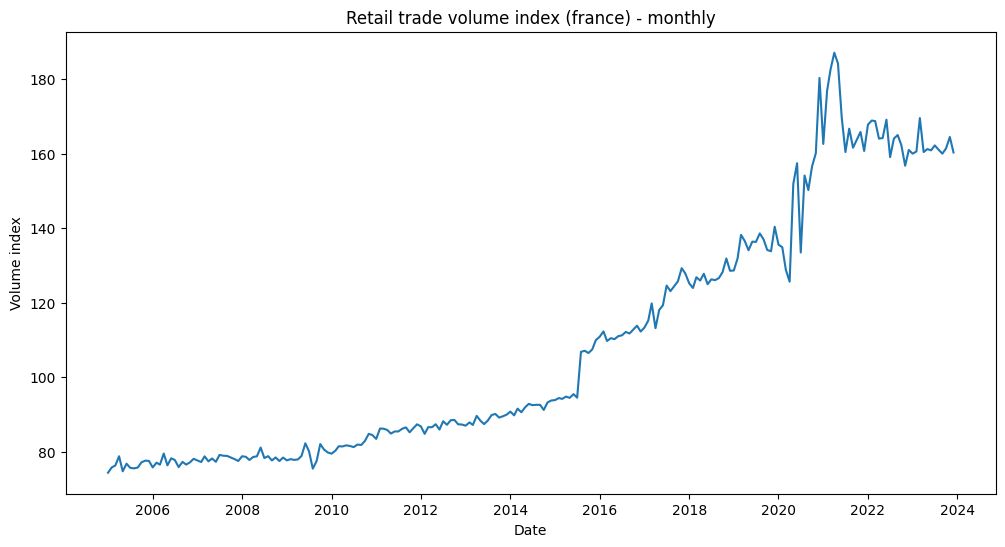

In [6]:
import matplotlib.pyplot as plt

df = df.sort_values("Period")

plt.figure(figsize=(12,6))
plt.plot(df["Period"], df["Value"])
plt.title("Retail trade volume index (france) - monthly")
plt.xlabel("Date")
plt.ylabel("Volume index")
plt.show()

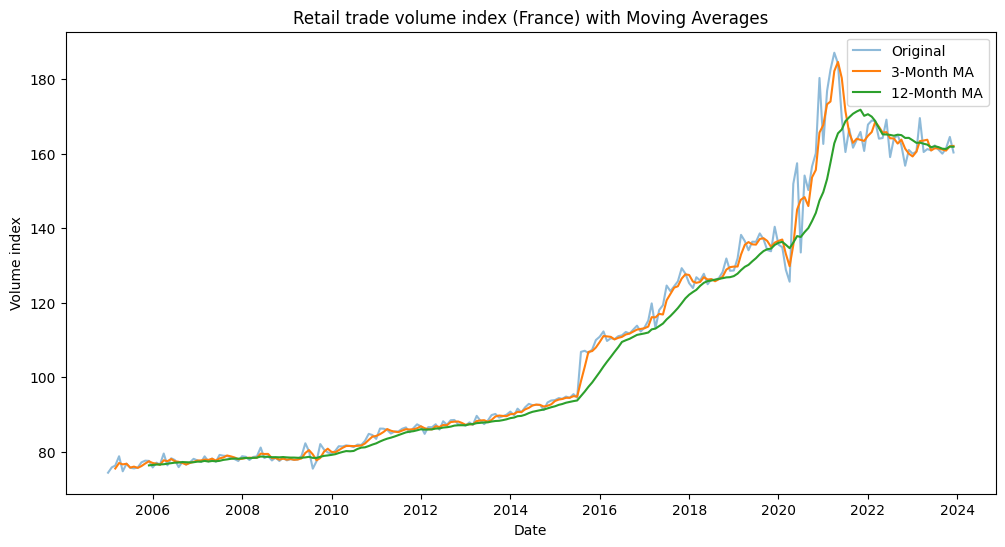

In [7]:
df["MA_3"] = df["Value"].rolling(window=3).mean()
df["MA_12"] = df["Value"].rolling(window=12).mean()

plt.figure(figsize=(12,6))

plt.plot(df["Period"], df["Value"], label="Original", alpha=0.5)
plt.plot(df["Period"], df["MA_3"], label="3-Month MA")
plt.plot(df["Period"], df["MA_12"], label="12-Month MA")

plt.title("Retail trade volume index (France) with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Volume index")
plt.legend()
plt.show()

In [8]:
df["covid_period"] = (
    (df["Period"] >= "2020-03-01") &
     (df["Period"] <= "2021-12-01")
)

df[["Period","Value","covid_period"]].head()

,Period,Value,covid_period
230,2005-01-01,74.41,False
229,2005-02-01,75.86,False
228,2005-03-01,76.33,False
227,2005-04-01,78.83,False
226,2005-05-01,74.79,False


In [9]:
df = df.sort_values("Period")
df["yoy_pct"] = df["Value"].pct_change(12) * 100
df[["Period","Value","yoy_pct"]].tail(15)

,Period,Value,yoy_pct
17,2022-10-01,162.30,-0.873389
16,2022-11-01,156.79,-5.468467
15,2022-12-01,161.03,0.167952
14,2023-01-01,160.03,-4.647560
13,2023-02-01,160.61,-4.919489
12,2023-03-01,169.58,0.479943
11,2023-04-01,160.47,-2.188224
10,2023-05-01,161.26,-1.808439
9,2023-06-01,160.93,-4.859592
8,2023-07-01,162.25,1.973477


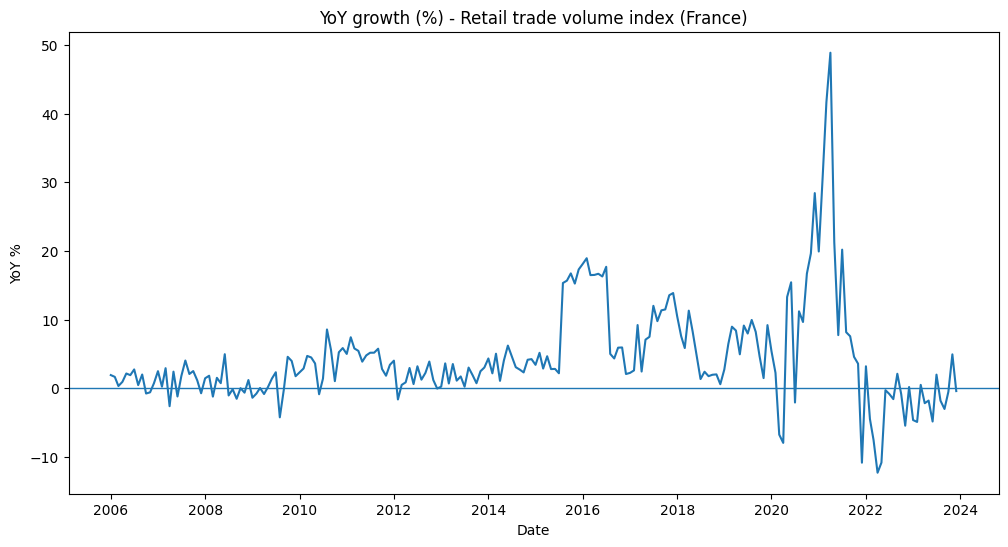

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["Period"], df["yoy_pct"])
plt.axhline(0, linewidth=1)
plt.title("YoY growth (%) - Retail trade volume index (France)")
plt.xlabel("Date")
plt.ylabel("YoY %")
plt.show()

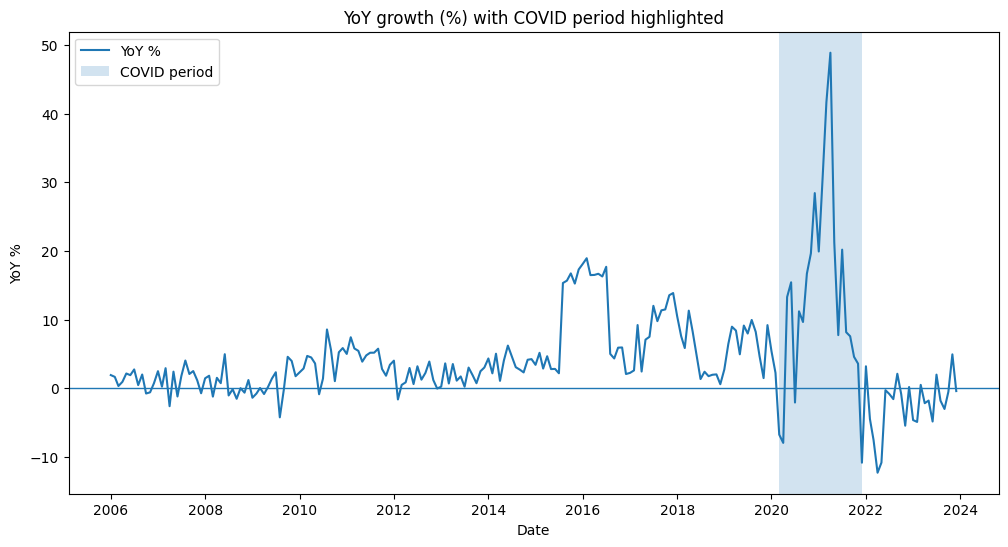

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df["Period"], df["yoy_pct"], label="YoY %")
plt.axhline(0, linewidth=1)

# Shade COVID period
plt.axvspan(pd.to_datetime("2020-03-01"), pd.to_datetime("2021-12-01"), alpha=0.2, label="COVID period")

plt.title("YoY growth (%) with COVID period highlighted")
plt.xlabel("Date")
plt.ylabel("YoY %")
plt.legend()
plt.show()

In [12]:
pre = df[df["Period"] < "2020-03-01"]["yoy_pct"].dropna()
covid_post = df[df["Period"] >= "2020-03-01"]["yoy_pct"].dropna()

print("Pre-COVID: mean =", pre.mean(), "| std =", pre.std())
print("Post-COVID: mean =", covid_post.mean(), "| std =", covid_post.std())

Pre-COVID: mean = 4.276647809681512 | std = 4.684881227009841
Post-COVID: mean = 5.339101676032149 | std = 13.42453156096479


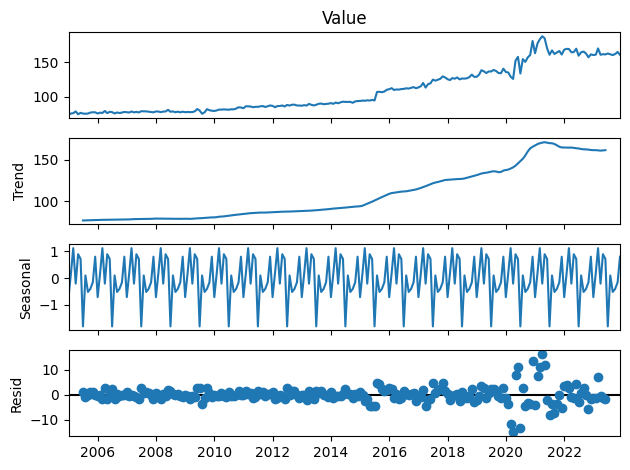

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_ts = df.set_index("Period")

decomposition = seasonal_decompose(df_ts["Value"], model="additive", period=12)

decomposition.plot()
plt.show()

In [14]:
df.tail()

,Period,Value,Status,MA_3,MA_12,covid_period,yoy_pct
7,2023-08-01,161.09,SD,161.423333,161.780833,False,-1.822282
6,2023-09-01,160.03,SD,161.123333,161.364167,False,-3.029752
5,2023-10-01,161.45,SD,160.856667,161.293333,False,-0.523722
4,2023-11-01,164.52,SD,162.000000,161.937500,False,4.930161
3,2023-12-01,160.35,P,162.106667,161.880833,False,-0.422282


In [15]:
train = df[df["Period"] < "2023-01-01"]
test = df[df["Period"] >= "2023-01-01"]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 216
Test size: 12


In [16]:
naive_forecast = [train["Value"].iloc[-1]] * len(test)

In [17]:
import pandas as pd

forecast_df = pd.DataFrame(({
    "Period": test["Period"],
    "Value": test["Value"],
    "Naive Forecast": naive_forecast
}))

forecast_df

,Period,Value,Naive Forecast
14,2023-01-01,160.03,161.03
13,2023-02-01,160.61,161.03
12,2023-03-01,169.58,161.03
11,2023-04-01,160.47,161.03
10,2023-05-01,161.26,161.03
9,2023-06-01,160.93,161.03
8,2023-07-01,162.25,161.03
7,2023-08-01,161.09,161.03
6,2023-09-01,160.03,161.03
5,2023-10-01,161.45,161.03


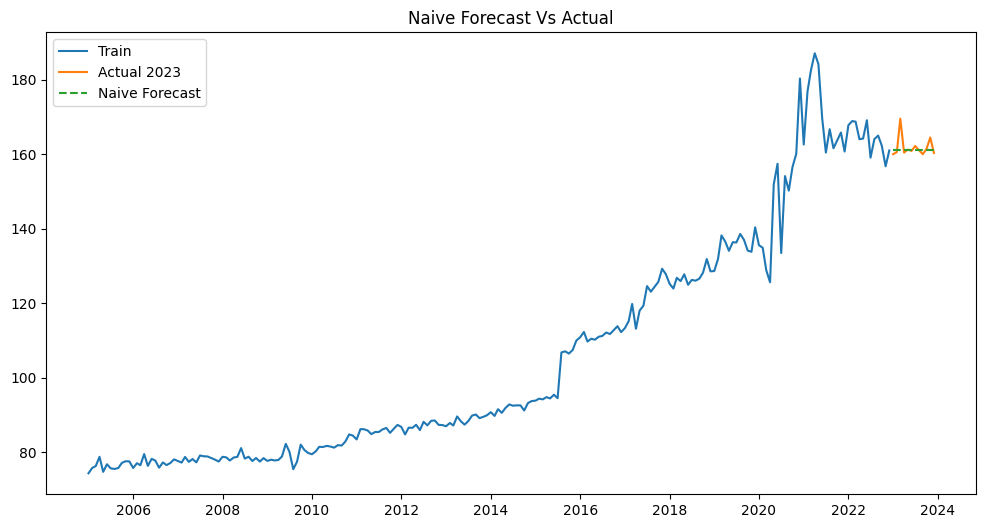

In [18]:
plt.figure(figsize=(12,6))

plt.plot(train["Period"], train["Value"], label="Train")
plt.plot(test["Period"], test["Value"], label="Actual 2023")
plt.plot(test["Period"], naive_forecast, label="Naive Forecast", linestyle="--")

plt.legend()
plt.title("Naive Forecast Vs Actual")
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test["Value"], naive_forecast)

print("Naive Forecast MAE:", mae)

Naive Forecast MAE: 1.4774999999999991


In [20]:
seasonal_naive = train["Value"].iloc[-12:].values

seasonal_forecast = list(seasonal_naive)

mae_seasonal = mean_absolute_error(test["Value"], seasonal_forecast)

print("seasonal Native MAE:", mae_seasonal)

seasonal Native MAE: 4.340833333333336


In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error

full = df.sort_values("Period").copy()

preds_ma3 = []

for date in test["Period"]:
  history = full[full["Period"] < date]["Value"].tail(3)
  preds_ma3.append(history.mean())

mae_ma3 = mean_absolute_error(test["Value"], preds_ma3)
print("MA(3) Forecast MAE:", mae_ma3)

MA(3) Forecast MAE: 2.268055555555558


In [23]:
train_ts = train.set_index("Period")
test_ts = test.set_index("Period")

In [24]:
from statsmodels.tsa.holtwinters import Holt

model = Holt(train["Value"]).fit()

holt_forecast = model.forecast(len(test))

mae_holt =  mean_absolute_error(test["Value"], holt_forecast)

print("Holt Forecast MAE:", mae_holt)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Holt Forecast MAE: 2.3760358835203803


In [25]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Value"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.227777138185349
p-value: 0.9737771974291951


In [27]:
df = df.sort_values("Period").copy()

df["diff1"] = df["Value"].diff()

df[["Period", "Value", "diff1"]].head(15)

,Period,Value,diff1
230,2005-01-01,74.41,NaN
229,2005-02-01,75.86,1.45
228,2005-03-01,76.33,0.47
227,2005-04-01,78.83,2.50
226,2005-05-01,74.79,-4.04
225,2005-06-01,76.83,2.04
224,2005-07-01,75.74,-1.09
223,2005-08-01,75.57,-0.17
222,2005-09-01,75.81,0.24
221,2005-10-01,77.20,1.39


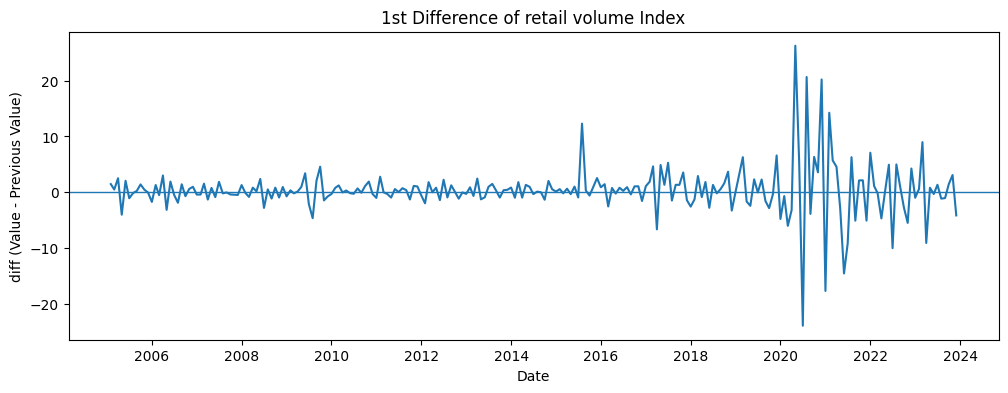

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df["Period"], df["diff1"])
plt.axhline(0, linewidth=1)
plt.title("1st Difference of retail volume Index")
plt.xlabel("Date")
plt.ylabel("diff (Value - Previous Value)")
plt.show()

In [29]:
from statsmodels.tsa.stattools import adfuller

diff1 = df["diff1"].dropna()

result = adfuller(diff1)

print("ADF Statistic (diff1):", result[0])
print("p-value (diff1):", result[1])

ADF Statistic (diff1): -4.620407099051746
p-value (diff1): 0.00011843288864409882


In [32]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["Value"], order=(1,1,1))
model_fit = model.fit()

arima_forecast = model_fit.forecast(steps=len(test))

mae_arima = mean_absolute_error(test["Value"], arima_forecast)

print("ARIMA(1,1,1) MAE:", mae_arima)

ARIMA(1,1,1) MAE: 1.6488882441422277


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

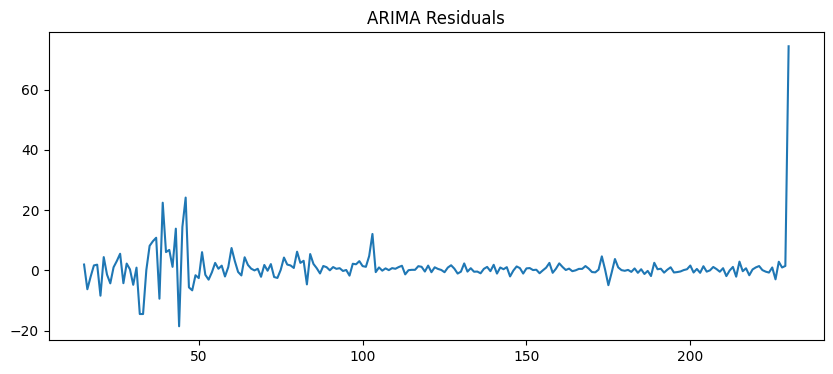

In [33]:
residuals = model_fit.resid
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()

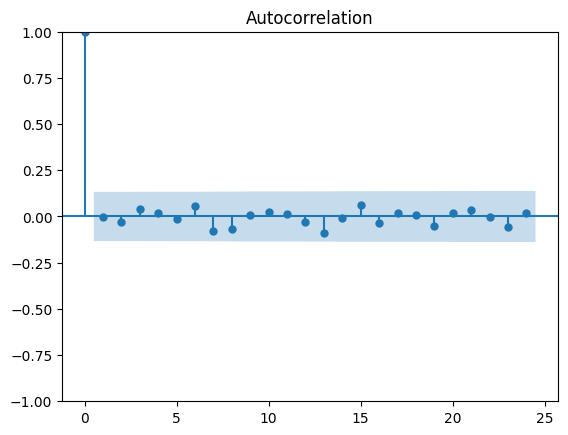

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals)
plt.show()